In [ ]:
# This is a simple workflow to calculate BMI from the given height and weight.

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [27]:
# Define State of the Graph
class BMI_State(TypedDict):
    height: float  # in meters
    weight: float  # in kilograms
    bmi: float     # Body Mass Index
    category: str  # BMI Category (e.g., Underweight, Normal, Overweight, Obesity)

In [6]:
# A Function to calculate BMI that will be used in the workflow
def calculate_bmi(state: BMI_State) -> BMI_State:
    
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['bmi'] = bmi
    return state



In [28]:
# A Function to catagorize the BMI that will be used in the workflow
def categorize_bmi(state: BMI_State) -> BMI_State:
    bmi = state['bmi']
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 24.9:
        category = "Normal"
    elif 25 <= bmi < 29.9:
        category = "Overweight"
    else:
        category = "Obesity"
    
    state['category'] = category
    return state

In [29]:
# Define a greaphh
graph = StateGraph(BMI_State)

In [ ]:
# Add nodes to the graph
graph.add_node("Calculate_BMI", calculate_bmi)

ValueError: Node `Calculate_BMI` already present.

In [ ]:
# Add another node.
graph.add_node("Categorize_BMI", categorize_bmi)

In [34]:
# Add edges to the nodes to create a graph workflow.
graph.add_edge(START, "Calculate_BMI")
graph.add_edge("Calculate_BMI", "Categorize_BMI")
graph.add_edge("Categorize_BMI", END)

In [38]:
# Compile the graph to create an executable workflow
compiled_workflow = graph.compile()


In [52]:
# Execute the workflow with some input data/state
input_state = {
    'height': 1.82,  # in meters
    'weight': 62     # in kilograms
}

final_state = compiled_workflow.invoke(input_state)
print(final_state)

{'height': 1.82, 'weight': 62, 'bmi': 18.717546190073662, 'category': 'Normal'}


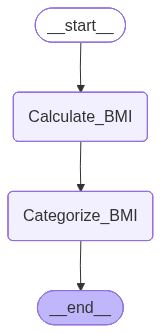

In [53]:
# Print the Graph structure
from IPython.display import Image
Image(compiled_workflow.get_graph().draw_mermaid_png())